# Comparación de Modelos — Justificación de XGBoost
**Universidad Diego Portales | Data Science | Entrega 2**

Este notebook compara múltiples algoritmos sobre el **mismo dataset (~31K registros)** y las **mismas features**, sin GridSearchCV ni KFold, para justificar la elección de XGBoost como modelo principal.

Modelos comparados:
1. Regresión Lineal (referencia mínima)
2. Ridge (regularización L2)
3. Lasso (regularización L1)
4. Random Forest
5. Gradient Boosting (sklearn)
6. **XGBoost** ← ganador esperado

In [45]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import xgboost as xgb

np.random.seed(42)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110
print('Setup completo ✓')

Setup completo ✓


## 1. Carga y Limpieza del Dataset

In [46]:
BASE = Path(r'C:\Users\gcamp\Downloads\UDP\Proyecto DataSciense')
df_raw = pd.read_csv(BASE / 'datos_combinados_entrega2.csv')
print(f'Dataset cargado: {df_raw.shape}')
print(df_raw['source'].value_counts())

Dataset cargado: (34502, 8)
source
yapo                   32743
chileautos_original      695
auto_cl                  288
autosusados              287
autocosmos.cl            262
autopia                  129
kavak                     98
Name: count, dtype: int64


In [47]:
def limpiar_combustible(v):
    if pd.isna(v): return np.nan
    v = str(v).lower()
    if 'diesel' in v or 'petróleo' in v or 'petroleo' in v: return 'Diesel'
    if 'bencina' in v or 'gasolina' in v or 'gasoline' in v or 'petrol' in v: return 'Bencina'
    if 'híbrido' in v or 'hibrido' in v or 'hybrid' in v: return 'Híbrido'
    if 'eléctrico' in v or 'electrico' in v or 'electric' in v: return 'Eléctrico'
    if 'gas' in v: return 'Gas'
    return 'Otro'

def limpiar_transmision(v):
    if pd.isna(v): return np.nan
    v = str(v).lower().strip()
    if v in ['m', 'manual', 'mecánica', 'mecanica', 'mechanical']: return 'Manual'
    if 'auto' in v or 'cvt' in v or 'tiptronic' in v or 'dsg' in v: return 'Automática'
    return np.nan

def iqr_filter(df, col):
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    return df[(df[col] >= Q1 - 1.5*IQR) & (df[col] <= Q3 + 1.5*IQR)]

df = df_raw.copy()
df.rename(columns={'Ano': 'Ano'}, inplace=True)
for col in ['Ano', 'Kilometraje', 'price']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['Combustible'] = df['Combustible'].apply(limpiar_combustible)
df['Transmision']  = df['Transmision'].apply(limpiar_transmision)
for col in ['Combustible', 'Transmision']:
    df[col] = df[col].fillna(df[col].mode()[0])

df = df.dropna(subset=['Marca', 'Modelo', 'Ano', 'Kilometraje', 'price'])
df = iqr_filter(df, 'price')
df = iqr_filter(df, 'Kilometraje')
df = df[(df['price'] > 500_000) & (df['Ano'] >= 1990) & (df['Ano'] <= 2026) & (df['Kilometraje'] > 0)]

df['antigüedad_auto'] = 2026 - df['Ano']
df['Marca']  = df['Marca'].str.strip().str.title()
df['Modelo'] = df['Modelo'].str.strip().str.title()
df = df.reset_index(drop=True)

print(f'Dataset limpio: {len(df):,} registros')

Dataset limpio: 32,371 registros


## 2. Separación de Datos (igual que Entrega 2)

Replicamos exactamente la misma separación del notebook principal para usar el mismo dataset de entrenamiento.

In [48]:
# Separar Chileautos (se usan para calibrar umbrales, no para entrenar)
df_chileautos = df[df['source'] == 'chileautos_original'].copy().reset_index(drop=True)
df_sin_chile  = df[df['source'] != 'chileautos_original'].copy()

# Separar 15 autos demo (fuentes distintas a Yapo)
df_sin_chile = df_sin_chile.reset_index(drop=True)
df_no_yapo   = df_sin_chile[df_sin_chile['source'] != 'yapo'].copy()

terciles = pd.qcut(df_no_yapo['price'], q=3, labels=['bajo', 'medio', 'alto'])
df_no_yapo = df_no_yapo.copy()
df_no_yapo['_tercil'] = terciles

demo_idx = []
for t in ['bajo', 'medio', 'alto']:
    sub = df_no_yapo[df_no_yapo['_tercil'] == t]
    demo_idx.extend(sub.sample(n=min(5, len(sub)), random_state=42).index.tolist())

df_model = df_sin_chile.drop(index=demo_idx).reset_index(drop=True)

print(f'Chileautos (umbral): {len(df_chileautos):,}')
print(f'Demo (presentación): {len(demo_idx)}')
print(f'Dataset para modelos: {len(df_model):,}')

Chileautos (umbral): 604
Demo (presentación): 15
Dataset para modelos: 31,752


## 3. Preparación de Features y Split Train/Test

In [49]:
NUM_FEATURES = ['antigüedad_auto', 'Kilometraje']
CAT_OHE      = ['Combustible', 'Transmision']
CAT_TARGET   = ['Marca', 'Modelo']
TARGET_ORIG  = 'price'

def target_encode_fit(series, target):
    global_mean = target.mean()
    mapping = target.groupby(series).mean().to_dict()
    return mapping, global_mean

def target_encode_transform(series, mapping, global_mean):
    return series.map(mapping).fillna(global_mean)

X      = df_model[NUM_FEATURES + CAT_OHE + CAT_TARGET + [TARGET_ORIG]].copy()
y_log  = np.log1p(df_model[TARGET_ORIG])
y_orig = df_model[TARGET_ORIG]

price_bins = pd.qcut(y_orig, q=5, labels=False, duplicates='drop')
X_train, X_test, y_train, y_test = train_test_split(
    X, y_log, test_size=0.2, random_state=42, stratify=price_bins
)

# Target encoding (fit solo en train)
te_maps, te_globals = {}, {}
for col in CAT_TARGET:
    te_maps[col], te_globals[col] = target_encode_fit(X_train[col], y_train)

# OHE (fit solo en train)
ohe_train = pd.get_dummies(X_train[CAT_OHE], prefix=CAT_OHE, drop_first=True)
ohe_test  = pd.get_dummies(X_test[CAT_OHE],  prefix=CAT_OHE, drop_first=True)
ohe_test  = ohe_test.reindex(columns=ohe_train.columns, fill_value=0)

def build_encoded(X_split, ohe_df):
    num = X_split[NUM_FEATURES].reset_index(drop=True)
    te  = pd.DataFrame({
        f'{c}_te': target_encode_transform(X_split[c], te_maps[c], te_globals[c])
        for c in CAT_TARGET
    }).reset_index(drop=True)
    return pd.concat([num, te, ohe_df.reset_index(drop=True)], axis=1)

X_train_enc = build_encoded(X_train, ohe_train)
X_test_enc  = build_encoded(X_test,  ohe_test)

# Escalar para modelos lineales
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_enc)
X_test_sc  = scaler.transform(X_test_enc)

print(f'Train: {len(X_train_enc):,} | Test: {len(X_test_enc):,}')
print(f'Features: {list(X_train_enc.columns)}')

Train: 25,401 | Test: 6,351
Features: ['antigüedad_auto', 'Kilometraje', 'Marca_te', 'Modelo_te', 'Combustible_Diesel', 'Combustible_Eléctrico', 'Combustible_Gas', 'Combustible_Híbrido', 'Combustible_Otro', 'Transmision_Manual']


## 4. Entrenamiento de Todos los Modelos

Todos con hiperparámetros por defecto o razonables. 

In [50]:
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def evaluar(model, X_tr, y_tr, X_te, y_te, name, scaled=False):
    Xtr = X_tr; Xte = X_te
    model.fit(Xtr, y_tr)
    p_tr = model.predict(Xtr)
    p_te = model.predict(Xte)
    y_tr_clp = np.expm1(y_tr); y_te_clp = np.expm1(y_te)
    p_tr_clp = np.expm1(p_tr); p_te_clp = np.expm1(p_te)
    return {
        'Modelo':         name,
        'R² Train':       round(r2_score(y_tr, p_tr), 3),
        'R² Test':        round(r2_score(y_te, p_te), 3),
        'GAP R²':         round(r2_score(y_tr, p_tr) - r2_score(y_te, p_te), 3),
        'MAE Test (M$)':  round(mean_absolute_error(y_te_clp, p_te_clp) / 1e6, 3),
        'MAPE Test (%)':  round(mape(y_te_clp, p_te_clp), 1),
    }, model

results = []
modelos = {}

print('Entrenando modelos...\n')

# 1. Regresión Lineal
m, obj = evaluar(LinearRegression(), X_train_sc, y_train, X_test_sc, y_test, 'Regresión Lineal')
results.append(m); modelos['Regresión Lineal'] = obj
print(f"  {m['Modelo']:<25} MAPE={m['MAPE Test (%)']:.1f}%  R²={m['R² Test']:.3f}")

# 2. Ridge
m, obj = evaluar(Ridge(alpha=1.0), X_train_sc, y_train, X_test_sc, y_test, 'Ridge (α=1)')
results.append(m); modelos['Ridge'] = obj
print(f"  {m['Modelo']:<25} MAPE={m['MAPE Test (%)']:.1f}%  R²={m['R² Test']:.3f}")

# 3. Lasso
m, obj = evaluar(Lasso(alpha=0.001), X_train_sc, y_train, X_test_sc, y_test, 'Lasso (α=0.001)')
results.append(m); modelos['Lasso'] = obj
print(f"  {m['Modelo']:<25} MAPE={m['MAPE Test (%)']:.1f}%  R²={m['R² Test']:.3f}")

# 4. Random Forest
m, obj = evaluar(RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
                  X_train_enc, y_train, X_test_enc, y_test, 'Random Forest')
results.append(m); modelos['Random Forest'] = obj
print(f"  {m['Modelo']:<25} MAPE={m['MAPE Test (%)']:.1f}%  R²={m['R² Test']:.3f}")

# 5. Gradient Boosting (sklearn)
m, obj = evaluar(GradientBoostingRegressor(n_estimators=200, max_depth=5,
                                            learning_rate=0.1, random_state=42),
                  X_train_enc, y_train, X_test_enc, y_test, 'Gradient Boosting')
results.append(m); modelos['Gradient Boosting'] = obj
print(f"  {m['Modelo']:<25} MAPE={m['MAPE Test (%)']:.1f}%  R²={m['R² Test']:.3f}")

# 6. XGBoost
m, obj = evaluar(xgb.XGBRegressor(n_estimators=200, max_depth=5, learning_rate=0.1,
                                    random_state=42, verbosity=0),
                  X_train_enc, y_train, X_test_enc, y_test, 'XGBoost')
results.append(m); modelos['XGBoost'] = obj
print(f"  {m['Modelo']:<25} MAPE={m['MAPE Test (%)']:.1f}%  R²={m['R² Test']:.3f}")

print('\nListo ✓')

Entrenando modelos...

  Regresión Lineal          MAPE=25.0%  R²=0.724
  Ridge (α=1)               MAPE=25.0%  R²=0.724
  Lasso (α=0.001)           MAPE=25.0%  R²=0.723
  Random Forest             MAPE=19.9%  R²=0.791
  Gradient Boosting         MAPE=19.8%  R²=0.802
  XGBoost                   MAPE=19.9%  R²=0.802

Listo ✓


## 5. Tabla Comparativa

In [51]:
df_res = pd.DataFrame(results).set_index('Modelo')
df_res_sorted = df_res.sort_values('MAPE Test (%)')

print('=== RANKING POR MAPE TEST (menor = mejor) ===')
print(df_res_sorted.to_string())

winner = df_res_sorted.index[0]
print(f'\nGanador: {winner}')
print(f'   MAPE={df_res_sorted.loc[winner, "MAPE Test (%)"]:.1f}%  '
      f'R²={df_res_sorted.loc[winner, "R² Test"]:.3f}  '
      f'GAP={df_res_sorted.loc[winner, "GAP R²"]:.3f}')

=== RANKING POR MAPE TEST (menor = mejor) ===
                   R² Train  R² Test  GAP R²  MAE Test (M$)  MAPE Test (%)
Modelo                                                                    
Gradient Boosting     0.849    0.802   0.048          1.506           19.8
Random Forest         0.971    0.791   0.180          1.462           19.9
XGBoost               0.845    0.802   0.043          1.512           19.9
Regresión Lineal      0.733    0.724   0.009          1.952           25.0
Lasso (α=0.001)       0.733    0.723   0.010          1.953           25.0
Ridge (α=1)           0.733    0.724   0.009          1.952           25.0

Ganador: Gradient Boosting
   MAPE=19.8%  R²=0.802  GAP=0.048


## 6. Visualización Comparativa

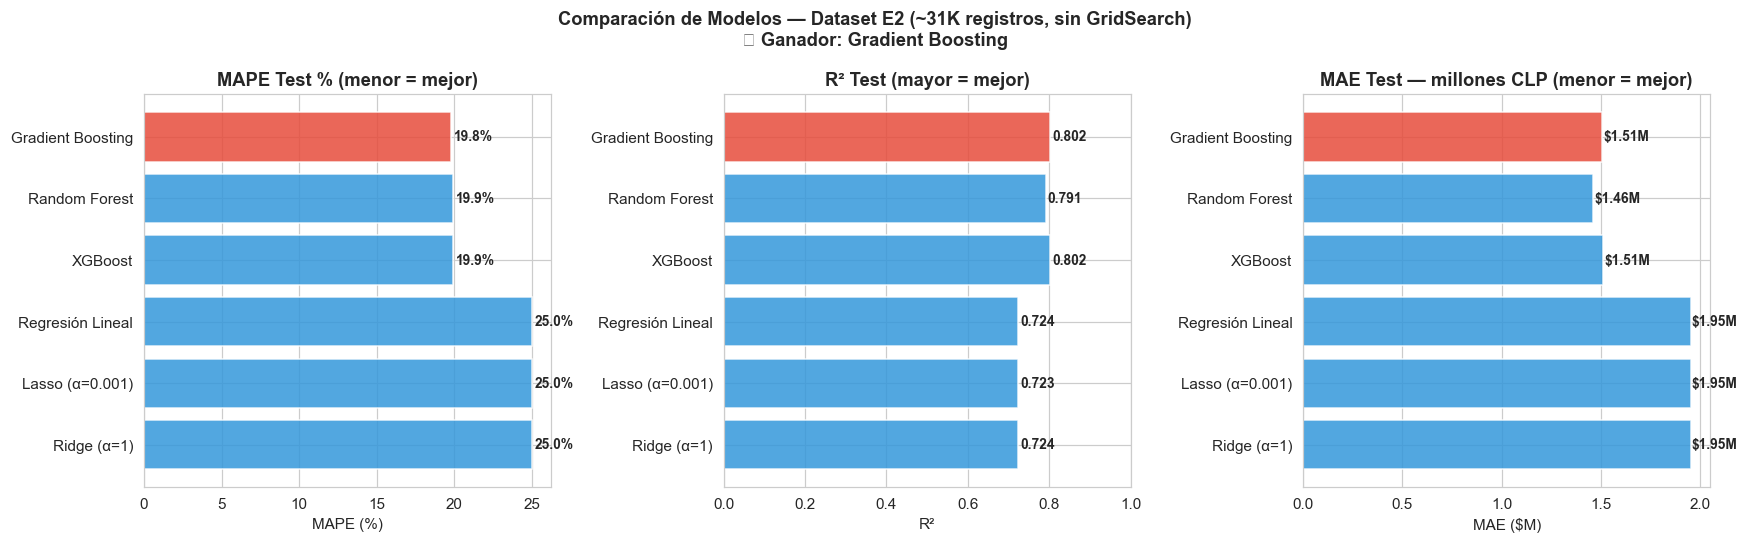

In [52]:
nombres = df_res_sorted.index.tolist()
# Resaltar ganador en rojo, el resto en azul
colors = ['#e74c3c' if n == winner else '#3498db' for n in nombres]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# MAPE
bars = axes[0].barh(nombres, df_res_sorted['MAPE Test (%)'], color=colors, alpha=0.85)
axes[0].invert_yaxis()
axes[0].set_title('MAPE Test % (menor = mejor)', fontweight='bold')
axes[0].set_xlabel('MAPE (%)')
for bar, v in zip(bars, df_res_sorted['MAPE Test (%)']):
    axes[0].text(v + 0.2, bar.get_y() + bar.get_height()/2,
                 f'{v:.1f}%', va='center', fontweight='bold', fontsize=9)

# R² Test
bars2 = axes[1].barh(nombres, df_res_sorted['R² Test'], color=colors, alpha=0.85)
axes[1].invert_yaxis()
axes[1].set_title('R² Test (mayor = mejor)', fontweight='bold')
axes[1].set_xlabel('R²')
axes[1].set_xlim(0, 1)
for bar, v in zip(bars2, df_res_sorted['R² Test']):
    axes[1].text(v + 0.005, bar.get_y() + bar.get_height()/2,
                 f'{v:.3f}', va='center', fontweight='bold', fontsize=9)

# MAE
bars3 = axes[2].barh(nombres, df_res_sorted['MAE Test (M$)'], color=colors, alpha=0.85)
axes[2].invert_yaxis()
axes[2].set_title('MAE Test — millones CLP (menor = mejor)', fontweight='bold')
axes[2].set_xlabel('MAE ($M)')
for bar, v in zip(bars3, df_res_sorted['MAE Test (M$)']):
    axes[2].text(v + 0.005, bar.get_y() + bar.get_height()/2,
                 f'${v:.2f}M', va='center', fontweight='bold', fontsize=9)

plt.suptitle(f'Comparación de Modelos — Dataset E2 (~31K registros, sin GridSearch)\n'
             f'🏆 Ganador: {winner}',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Desempate: GridSearchCV + KFold en Gradient Boosting vs XGBoost

Gradient Boosting ganó sin optimización. Ahora aplicamos GridSearchCV + KFold (k=5) a **ambos** para ver cuál es realmente mejor con sus mejores hiperparámetros.

In [53]:
from sklearn.model_selection import GridSearchCV, KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# ── Gradient Boosting optimizado ──────────────────────────────────────────
print('=== GridSearchCV — Gradient Boosting ===')
param_gb = {
    'n_estimators':  [100, 300],
    'max_depth':     [3, 5, 7],
    'learning_rate': [0.05, 0.1],
    'subsample':     [0.8, 1.0],
}
gs_gb = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_gb, cv=kf, scoring='neg_mean_absolute_error',
    n_jobs=-1, verbose=1
)
gs_gb.fit(X_train_enc, y_train)
print(f'Mejores parámetros GB: {gs_gb.best_params_}')

m_gb_opt, _ = evaluar(gs_gb.best_estimator_, X_train_enc, y_train,
                       X_test_enc, y_test, 'GB Optimizado')
print(f"  MAPE={m_gb_opt['MAPE Test (%)']:.1f}%  R²={m_gb_opt['R² Test']:.3f}")

=== GridSearchCV — Gradient Boosting ===
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Mejores parámetros GB: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300, 'subsample': 1.0}
  MAPE=18.8%  R²=0.809


In [54]:
# ── XGBoost optimizado ────────────────────────────────────────────────────
print('=== GridSearchCV — XGBoost ===')
param_xgb = {
    'n_estimators':     [100, 300],
    'max_depth':        [3, 5, 7],
    'learning_rate':    [0.05, 0.1],
    'subsample':        [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
}
gs_xgb = GridSearchCV(
    xgb.XGBRegressor(random_state=42, verbosity=0),
    param_xgb, cv=kf, scoring='neg_mean_absolute_error',
    n_jobs=-1, verbose=1
)
gs_xgb.fit(X_train_enc, y_train)
print(f'Mejores parámetros XGB: {gs_xgb.best_params_}')

m_xgb_opt, _ = evaluar(gs_xgb.best_estimator_, X_train_enc, y_train,
                         X_test_enc, y_test, 'XGB Optimizado')
print(f"  MAPE={m_xgb_opt['MAPE Test (%)']:.1f}%  R²={m_xgb_opt['R² Test']:.3f}")

=== GridSearchCV — XGBoost ===
Fitting 5 folds for each of 48 candidates, totalling 240 fits
Mejores parámetros XGB: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300, 'subsample': 1.0}
  MAPE=18.7%  R²=0.814


=== DESEMPATE: GB vs XGB — Con y Sin Optimización ===
                   R² Train  R² Test  GAP R²  MAE Test (M$)  MAPE Test (%)
Modelo                                                                    
Gradient Boosting     0.849    0.802   0.048          1.506           19.8
GB Optimizado         0.916    0.809   0.107          1.397           18.8
XGBoost               0.845    0.802   0.043          1.512           19.9
XGB Optimizado        0.905    0.814   0.091          1.392           18.7

 Ganador final: XGB Optimizado
   MAPE=18.7%  R²=0.814


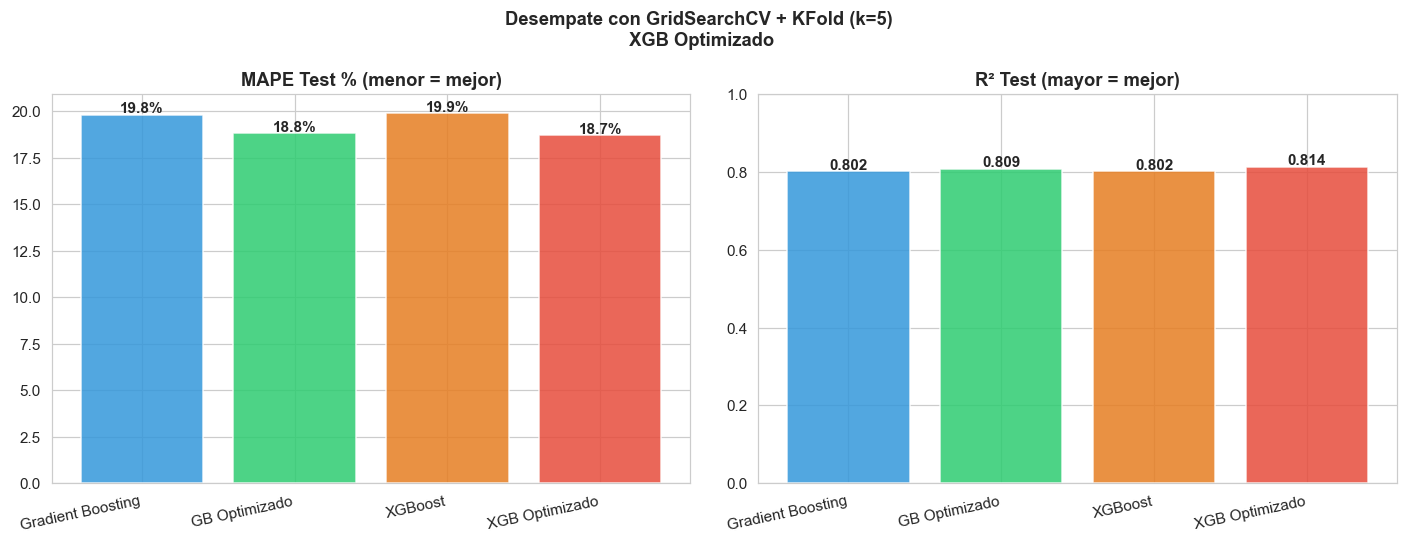

In [56]:
# ── Tabla final: 4 variantes comparadas ──────────────────────────────────
m_gb_base  = next(r for r in results if r['Modelo'] == 'Gradient Boosting')
m_xgb_base = next(r for r in results if r['Modelo'] == 'XGBoost')

desempate = pd.DataFrame([m_gb_base, m_gb_opt, m_xgb_base, m_xgb_opt]).set_index('Modelo')
print('=== DESEMPATE: GB vs XGB — Con y Sin Optimización ===')
print(desempate[['R² Train', 'R² Test', 'GAP R²', 'MAE Test (M$)', 'MAPE Test (%)']].to_string())

ganador_final = desempate['MAPE Test (%)'].idxmin()
print(f'\n Ganador final: {ganador_final}')
print(f'   MAPE={desempate.loc[ganador_final, "MAPE Test (%)"]:.1f}%  '
      f'R²={desempate.loc[ganador_final, "R² Test"]:.3f}')

# Gráfico comparativo
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
nombres_d = desempate.index.tolist()
colors_d  = ['#3498db', '#2ecc71', '#e67e22', '#e74c3c']

axes[0].bar(nombres_d, desempate['MAPE Test (%)'], color=colors_d, alpha=0.85)
axes[0].set_title('MAPE Test % (menor = mejor)', fontweight='bold')
axes[0].set_xticklabels(nombres_d, rotation=12, ha='right')
for i, v in enumerate(desempate['MAPE Test (%)']):
    axes[0].text(i, v + 0.1, f'{v:.1f}%', ha='center', fontweight='bold')

axes[1].bar(nombres_d, desempate['R² Test'], color=colors_d, alpha=0.85)
axes[1].set_title('R² Test (mayor = mejor)', fontweight='bold')
axes[1].set_ylim(0, 1)
axes[1].set_xticklabels(nombres_d, rotation=12, ha='right')
for i, v in enumerate(desempate['R² Test']):
    axes[1].text(i, v + 0.005, f'{v:.3f}', ha='center', fontweight='bold')

plt.suptitle(f'Desempate con GridSearchCV + KFold (k=5)\n {ganador_final}',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()